In [1]:
import os
import pandas as pd
import numpy as np
import h5py
from sqlalchemy import create_engine
from scipy import stats
import plotly.express as px
import toml
import psrc_theme

%matplotlib inline
from IPython.display import display, HTML

# to show plotly figures in quarto HTML file
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"
pio.templates.default = "simple_white+psrc_color" # set plotly template

input_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'input_configuration.toml'))
valid_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration', 'validation_configuration.toml'))
emme_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','emme_configuration.toml'))
network_config = toml.load(os.path.join(os.getcwd(), '..\\..\\..\\..\\configuration','network_configuration.toml'))

# create connection
conn = create_engine('sqlite:///../../../../inputs/db/'+input_config['db_name'])

# summary data location
csv_path = os.path.join(valid_config['model_dir'], 'outputs/validation')

# table format
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.1%}".format

## VMT

In [2]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))
df.index = df.county_name
df.loc['Total',:] = df.sum().values
df = df[['VMT','VHT','delay']]
df

,VMT,VHT,delay
county_name,,,
King,"42,898,107","1,349,767","145,423"
Kitsap,"4,693,193","140,772","3,539"
Outside Region,"826,067","33,811",6
Pierce,"18,577,044","554,025","29,833"
Snohomish,"17,627,828","543,960","47,419"
Total,"84,622,239","2,622,335","226,220"


In [3]:
df = pd.read_csv(os.path.join(valid_config['model_dir'], r'outputs/network/county_network.csv'))

df_obs = pd.read_sql("SELECT * FROM observed_vmt WHERE year="+str(input_config['base_year']), con=conn)
df_obs.rename(columns={'vmt': 'observed'}, inplace=True)

df = df[['county_name','VMT']].merge(df_obs, left_on='county_name', right_on='county')
df.rename(columns={'VMT': 'model'}, inplace=True)
df.index = df['county']
df[['observed','model']] = df[['observed','model']].astype('float')

df.loc['Total',:] = df.sum().values

df['% diff'] = (df['model']-df['observed'])/df['observed']
df[['% diff']] = df[['% diff']].applymap(format_percent)
df[['model','observed','% diff']]

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\2489709904.py:14: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,model,observed,% diff
county,,,
King,"42,898,107","43,820,112",-2.1%
Kitsap,"4,693,193","4,840,030",-3.0%
Pierce,"18,577,044","17,994,803",3.2%
Snohomish,"17,627,828","15,825,794",11.4%
Total,"83,796,172","82,480,739",1.6%


## Daily Traffic Counts

In [4]:
df = pd.read_csv(os.path.join(csv_path, 'daily_volume.csv'))
# df = df.groupby('@countid').agg({'modeled':'sum', 'observed':'first', '@facilitytype':'first'}).reset_index()
df[['modeled', 'observed']] = df[['modeled', 'observed']].astype('float')
_df = df.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\1873497911.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"27,406,928","26,180,425","-1,226,503",-4.5%
Busway,"4,664","3,618","-1,046",-22.4%
Collector,"2,753,947","2,437,645","-316,302",-11.5%
Freeway,"46,609,641","45,275,013","-1,334,628",-2.9%
HOV,"142,709","184,286","41,577",29.1%
Ramp,"449,106","339,421","-109,685",-24.4%
Total,"77,366,995","74,420,408","-2,946,587",-3.8%


In [5]:
#### Daily | By Facility Type - City of SeaTac

In [6]:
df1 = df[df['subarea_flag']==1]

In [7]:
_df = df1.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\608670790.py:5: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"1,923,947","1,688,271","-235,676",-12.2%
Collector,"315,623","189,335","-126,288",-40.0%
Freeway,"2,662,008","2,560,381","-101,627",-3.8%
HOV,"41,283","75,436","34,153",82.7%
Ramp,"102,262","63,703","-38,559",-37.7%
Total,"5,045,123","4,577,126","-467,997",-9.3%


In [8]:
#### Daily | By Facility Type - Other Counties

In [9]:
df2 = df[df['subarea_flag'] != 1]

In [10]:
_df = df2.groupby('@facilitytype').sum()[['observed', 'modeled']]
_df.loc['Total', :] = _df.sum().values
_df['diff'] = _df['modeled'] - _df['observed']
_df['percent_diff'] = _df['diff'] / _df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\1534906848.py:5: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
@facilitytype,,,,
Arterial,"25,482,981","24,492,154","-990,827",-3.9%
Busway,"4,664","3,618","-1,046",-22.4%
Collector,"2,438,324","2,248,310","-190,014",-7.8%
Freeway,"43,947,633","42,714,632","-1,233,001",-2.8%
HOV,"101,426","108,850","7,424",7.3%
Ramp,"346,844","275,718","-71,126",-20.5%
Total,"72,321,872","69,843,282","-2,478,590",-3.4%


In [11]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume_county_facility.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')

_df = df.groupby('county').sum()[['observed','modeled']]
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\4255960492.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,diff,percent_diff
county,,,,
King,"40,848,785","39,656,387","-1,192,398",-2.9%
Kitsap,"3,818,020","2,888,006","-930,014",-24.4%
Pierce,"19,755,510","18,987,248","-768,262",-3.9%
Snohomish,"12,944,680","12,888,767","-55,913",-0.4%
Total,"77,366,995","74,420,408","-2,946,587",-3.8%


In [12]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume_by_flow.csv'))
df[['modeled','observed']] = df[['modeled','observed']].astype('float')
df['diff'] = df['modeled']-df['observed']
df['diff2'] = df['diff']**2
volume_bins = ['>=0 & <10,000', '>=10,000 & < 25,000', '>=25,000 & <50,000', '>=50,000 & <100,000', '>=100,000', 'Total']
df['volume_bins'] = df['volbin'].map(pd.Series(volume_bins, dtype='category')).cat.reorder_categories(volume_bins, ordered=True)
_df = df.groupby('volume_bins', sort=True).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].applymap(format_percent)
_df[['rmse']] = _df[['rmse']].applymap(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]


C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\3353764135.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\3353764135.py:12: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\3353764135.py:13: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","8,720,611","6,001,828",1284,"-2,718,783",-31.2%,60.0%
">=10,000 & < 25,000","14,275,171","13,335,706",818,"-939,465",-6.6%,37.7%
">=25,000 & <50,000","18,070,025","18,125,370",503,"55,345",0.3%,29.5%
">=50,000 & <100,000","26,850,350","26,827,492",372,"-22,858",-0.1%,19.5%
">=100,000","9,450,926","10,131,546",75,"680,620",7.2%,19.5%
Total,"77,367,084","74,421,943",3052,"-2,945,141",-3.8%,34.3%


In [13]:
_df = df[df.subarea_flag==1].groupby('volume_bins', sort=True, observed=False).agg({'modeled':'sum', 'observed':'sum', 'nlinks':'count', 'diff2':'sum'}).reset_index().set_index('volume_bins')
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['rmse'] = ((_df['diff2']/(_df['nlinks']-1))**0.5)/(_df['observed']/_df['nlinks'])
_df[['percent_diff']] = _df[['percent_diff']].map(format_percent)
_df[['rmse']] = _df[['rmse']].map(format_percent)
_df.drop(columns='diff2').rename(columns={'nlinks':'ncounts'})[['observed', 'modeled', 'ncounts', 'diff', 'percent_diff', 'rmse']]

,observed,modeled,ncounts,diff,percent_diff,rmse
volume_bins,,,,,,
">=0 & <10,000","937,538","522,933",132,"-414,606",-44.2%,58.4%
">=10,000 & < 25,000","990,986","802,367",48,"-188,619",-19.0%,34.7%
">=25,000 & <50,000","895,870","893,360",25,"-2,510",-0.3%,32.7%
">=50,000 & <100,000","1,445,277","1,509,994",21,"64,717",4.5%,27.5%
">=100,000","775,540","848,590",5,"73,049",9.4%,33.8%
Total,"5,045,212","4,577,243",231,"-467,969",-9.3%,48.8%


## Daily Traffic Scatterplot

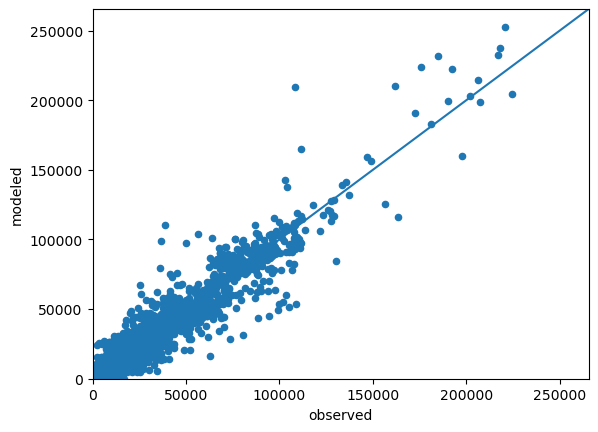

In [14]:
df = pd.read_csv(os.path.join(csv_path,'daily_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)

In [15]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

r^2: 0.9563896462360816


King r^2: 0.9738217513219635
Kitsap r^2: 0.9304887982808244
Pierce r^2: 0.968664405683912
Snohomish r^2: 0.858920956184406


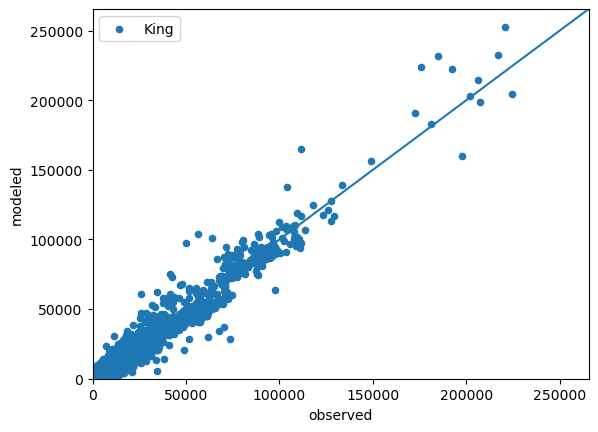

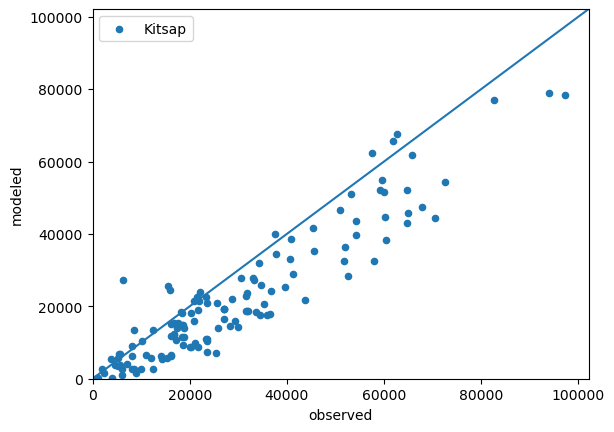

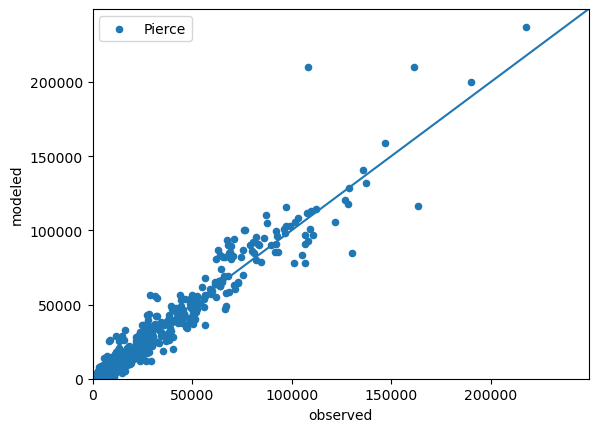

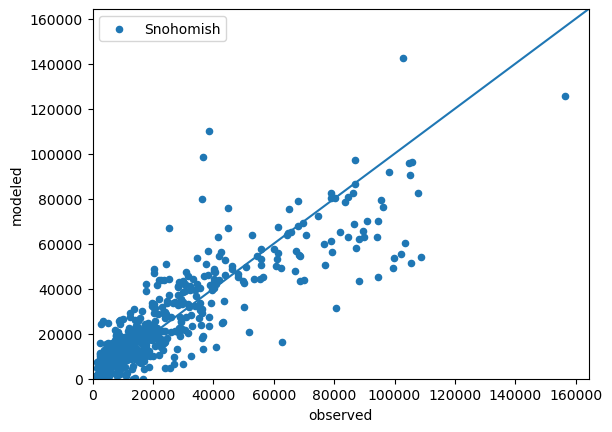

In [16]:
for county in np.unique(df['county']):
    _df = df[df['county'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=county)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(county) + ' r^2: ' + str(r_value))

In [17]:
### by City of SeaTac

Other r^2: 0.957616910611603
City of SeaTac r^2: 0.9432005744005681


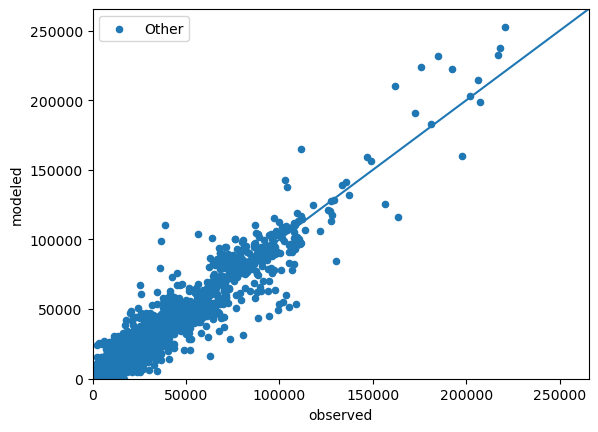

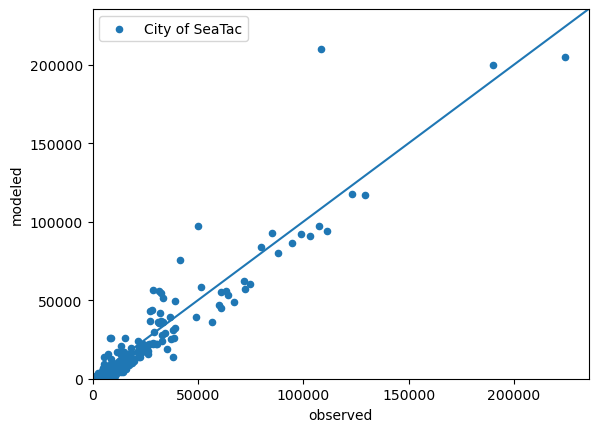

In [18]:
subarea_names = ['Other', 'City of SeaTac']
for county in np.unique(df[~df.county.isna()]['subarea_flag']):
    _df = df[df['subarea_flag'] == county]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=str(subarea_names[int(county)]))
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    print(str(subarea_names[int(county)]) + ' r^2: ' + str(r_value))

r^2 Freeway: 0.9216019692435444
r^2 Arterial: 0.8649560554430265


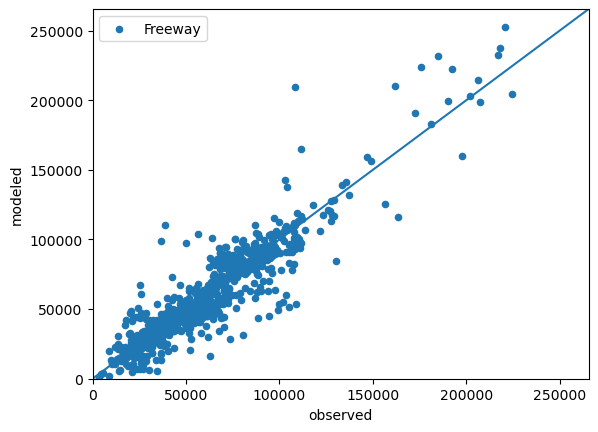

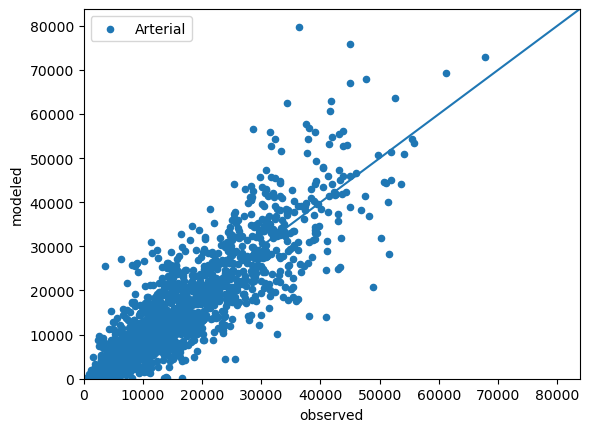

In [19]:
for factype in ['Freeway','Arterial']:
# for factype in ['Freeway']:
    _df = df[df['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

r^2 Freeway: 0.9154992686644309
r^2 Arterial: 0.8153680339810176


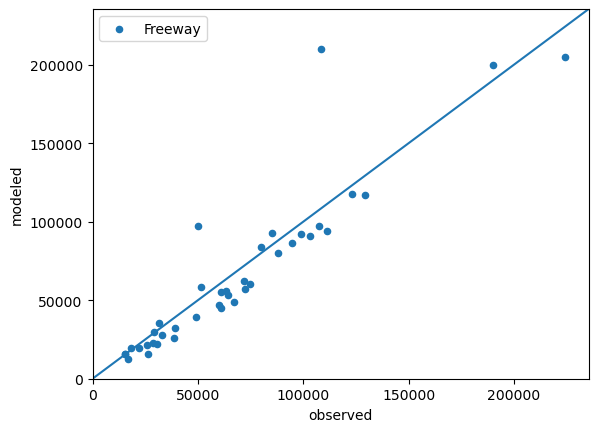

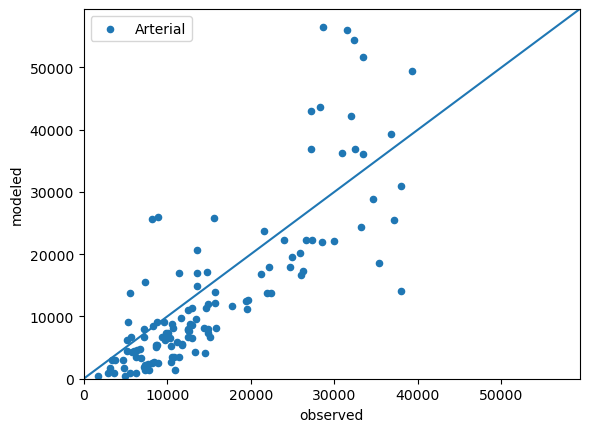

In [20]:
df1 = df[df['subarea_flag'] == 1]
for factype in ['Freeway','Arterial']:
    _df = df1[df1['@facilitytype'] == factype]
    ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
    lim = _df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
    print('r^2 ' + str(factype) + ': ' + str(r_value))

r^2 Freeway: 0.9222215901204665
r^2 Arterial: 0.8699067679549758


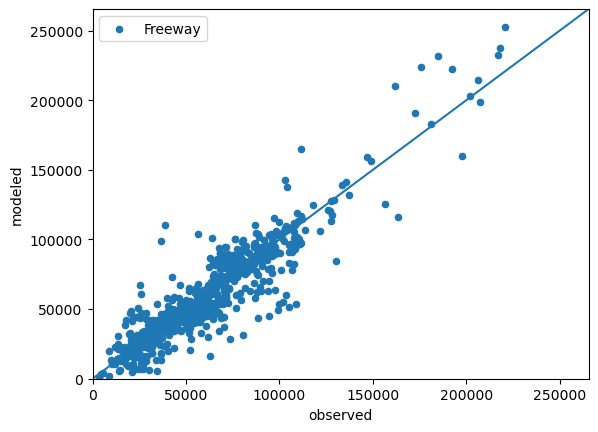

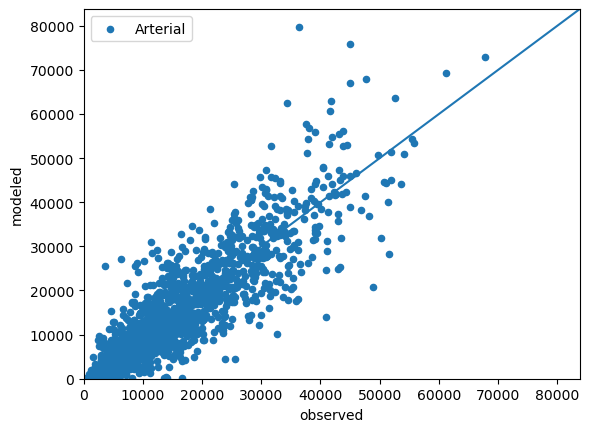

In [21]:
df2 = df[(df['subarea_flag'] != 1) & (~df.county.isna())]
if df2.shape[0] > 0:
    for factype in ['Freeway','Arterial']:
        _df = df2[df2['@facilitytype'] == factype]
        ax = _df.plot(kind='scatter', x='observed', y='modeled', label=factype)
        lim = _df[['observed','modeled']].max().max()*1.05
        ax.set_ylim(0,lim)
        ax.set_xlim(0,lim)
        x = np.linspace(*ax.get_xlim())
        ax.plot(x, x)
        slope, intercept, r_value, p_value, std_err = stats.linregress(_df['observed'],_df['modeled'])
        print('r^2 ' + str(factype) + ': ' + str(r_value))

In [22]:
## hourly volumnes

r^2: 0.7547769623154629


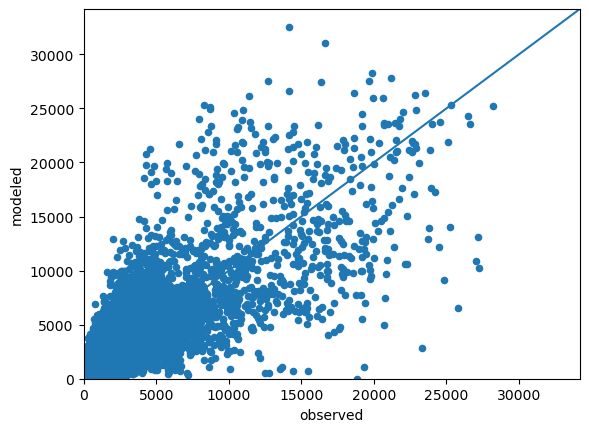

In [23]:
df = pd.read_csv(os.path.join(csv_path,'hourly_volume.csv'))
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2: ' + str(r_value))

In [24]:
## hourly volumnes - city of SeaTac

r^2: 0.8059727243052723


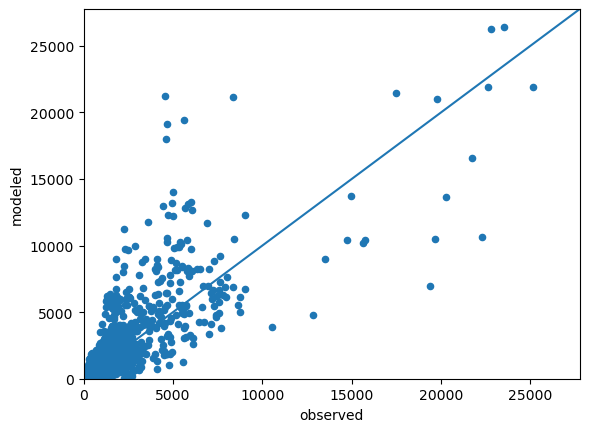

In [25]:
df1 = df[df['subarea_flag'] == 1]
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df1[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2: ' + str(r_value))

In [26]:
## hourly volumnes - Other

r^2: 0.6974536249798117


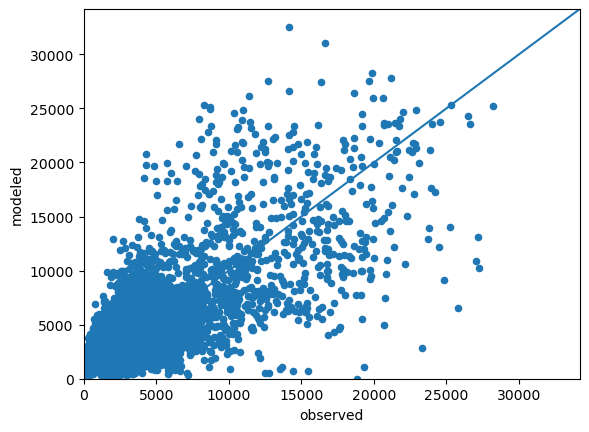

In [27]:
df2 = df[df['subarea_flag'] != 1]
ax = df2.plot(kind='scatter', x='observed', y='modeled')
lim = df2[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
print('r^2: ' + str(r_value))

## Screenlines

In [28]:
df = pd.read_csv(os.path.join(csv_path,'screenlines.csv'))
df = df.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df['diff'] = df['modeled']-df['observed']
df = pd.concat([df,df.sum(numeric_only=True).to_frame().T], ignore_index=True, axis=0)
df.at[df.index[-1], 'name'] = 'TOTAL'
#df.at['C', 'name'] = 10
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.sort_values(['county','observed'], ascending=[True, False])

C:\Users\aditya.gore\AppData\Local\Temp\3\ipykernel_71904\331908952.py:8: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,name,county,observed,modeled,diff,percent_diff
1,AUBURN - SOUTH KING,King,"592,476","509,972","-82,504",-13.9%
7,KENT,King,"559,335","288,643","-270,692",-48.4%
26,SHIP CANAL,King,"481,563","501,667","20,104",4.2%
25,SEATTLE - SOUTH OF CBD,King,"473,322","456,433","-16,889",-3.6%
11,MILL CREEK,King,"391,447","418,005","26,558",6.8%
27,SOUTH BELLEVUE,King,"389,700","350,854","-38,846",-10.0%
8,KIRKLAND-REDMOND,King,"380,783","378,205","-2,578",-0.7%
24,SEATTLE - NORTH,King,"356,051","341,770","-14,281",-4.0%
2,BOTHELL,King,"291,573","287,412","-4,161",-1.4%
9,LYNNWOOD-BOTHELL,King,"260,099","271,620","11,521",4.4%


r^2 : 0.9465010836961327


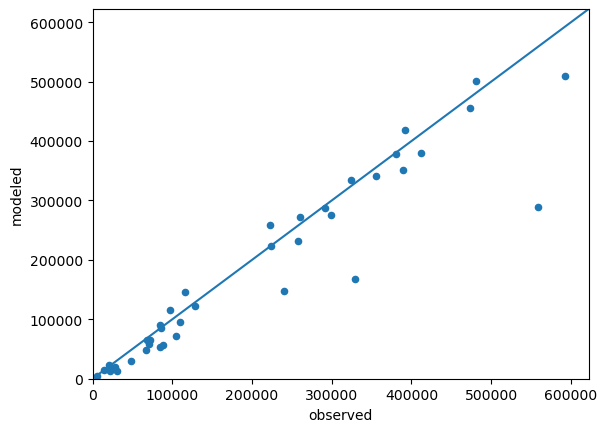

In [29]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

### Screenlines - City of SeaTac

In [30]:
df = pd.read_csv(os.path.join(csv_path,'screenlines.csv'))
df = df[~df.name.isin(['KENT','SEATAC'])]
df1 = df[(df['county'] == 'SeaTAC') & (df['name']!='KENT')].drop(columns='subarea_flag')
df1 = df1.groupby(['name', 'county'], as_index=False).agg({'observed':'first', 'modeled':'sum'})
df1['diff'] = df1['modeled'] - df1['observed']
df1 = pd.concat([df1,pd.DataFrame([df1.sum(numeric_only=True)], index=['Total'])], axis=0, ignore_index=False)
# df1.at[df1.index[-1], 'name'] = 'TOTAL'
#df1.at['C', 'name'] = 10
df1['percent_diff'] = df1['diff']/df1['observed']
df1['percent_diff'] = df1['percent_diff'].apply(format_percent)
df1.sort_values(['county','observed'], ascending=[True, False])

,name,county,observed,modeled,diff,percent_diff
7,S of SEA Airport,SeaTAC,"412,094","380,764","-31,330",-7.6%
10,W of IH 5,SeaTAC,"329,527","167,468","-162,059",-49.2%
2,N of S 160th St,SeaTAC,"240,460","147,610","-92,850",-38.6%
3,N of S 200th St,SeaTAC,"224,119","223,008","-1,111",-0.5%
12,W of SR 99,SeaTAC,"109,861","95,399","-14,462",-13.2%
5,S of S 128th St,SeaTAC,"88,338","56,760","-31,578",-35.7%
1,Expy/SR 99/Cargo N of S 170th St,SeaTAC,"84,725","53,404","-31,321",-37.0%
4,N of SEA Airport,SeaTAC,"66,919","48,164","-18,755",-28.0%
6,S of S 144th St,SeaTAC,"48,532","29,548","-18,984",-39.1%
9,W of Des Moines Mem'l N of 176th,SeaTAC,"30,790","12,165","-18,625",-60.5%


r^2 : 0.9435980761529761


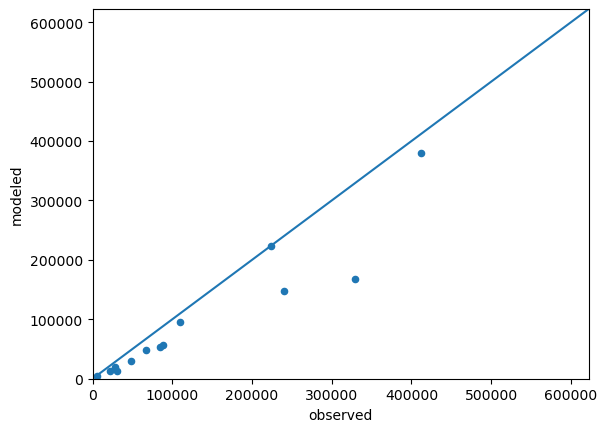

In [31]:
import warnings
warnings.filterwarnings('ignore')
df1 = df1.head(-1)
ax = df1.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df1['observed'],df1['modeled'])
print('r^2 : ' + str(r_value))

### Screenlines - Other

In [32]:
df2 = df[(df['county'] != 'SeaTAC') & ((df['name']!='KENT') | (df['name']!='SEATAC'))].drop(columns='subarea_flag').groupby(['name','county'],as_index=False).agg({'observed':'first','modeled':'sum'})
df2['diff'] = df2['modeled']-df2['observed']
df2 = pd.concat([df2,pd.DataFrame([df2.sum(numeric_only=True)], index=['Total'])], axis=0, ignore_index=False)
#df2.at['C', 'name'] = 10
df2['percent_diff'] = df2['diff']/df2['observed']
df2['percent_diff'] = df2['percent_diff'].apply(format_percent)
df2

,name,county,observed,modeled,diff,percent_diff
0,AGATE PASS BRIDGE,Kitsap,"21,000","22,522","1,522",7.2%
1,AUBURN - SOUTH KING,King,"592,476","509,972","-82,504",-13.9%
2,BOTHELL,King,"291,573","287,412","-4,161",-1.4%
3,CROSS SOUND,Kitsap,"14,302","13,997",-305,-2.1%
4,GIG HARBOR,Pierce,"84,875","91,146","6,271",7.4%
5,KIRKLAND-REDMOND,King,"380,783","378,205","-2,578",-0.7%
6,LYNNWOOD-BOTHELL,King,"260,099","271,620","11,521",4.4%
7,MAPLE VALLEY,King,"70,813","58,750","-12,063",-17.0%
8,MILL CREEK,King,"391,447","418,005","26,558",6.8%
9,NORTH KITSAP,Kitsap,"104,890","72,360","-32,530",-31.0%


r^2 : 0.9881393800727081


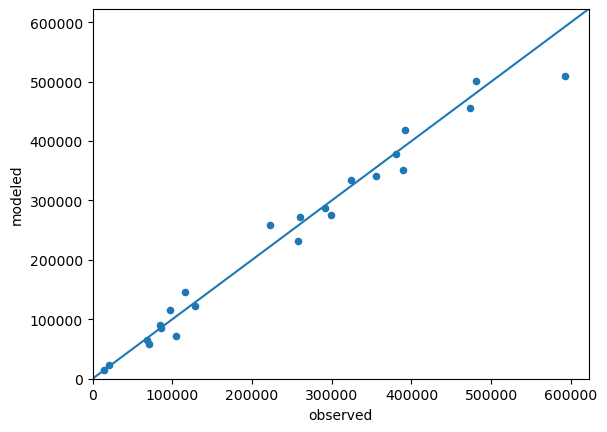

In [33]:
df2 = df2.head(-1)
if df2.shape[0] > 0:
    ax = df2.plot(kind='scatter', x='observed', y='modeled')
    lim = df[['observed','modeled']].max().max()*1.05
    ax.set_ylim(0,lim)
    ax.set_xlim(0,lim)
    x = np.linspace(*ax.get_xlim())
    ax.plot(x, x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df2['observed'],df2['modeled'])
    print('r^2 : ' + str(r_value))

# External Stations

In [34]:
df = pd.read_csv(os.path.join(csv_path,'external_volumes.csv'), index_col='location')
df = df.drop('diff', axis=1)
df['diff'] = df['modeled']-df['observed']
df = df.fillna(0)
df.loc['Total',['observed','modeled','diff']] = df[['observed','modeled','diff']].sum()
df['percent_diff'] = df['diff']/df['observed']
df[['percent_diff']] = df[['percent_diff']].applymap(format_percent)
df.replace('nan', '', regex=True)

,external_station,county,observed,modeled,diff,percent_diff
location,,,,,,
I-5 to Olympia,"3,733",Pierce,"129,250","131,567","2,317",1.8%
I-5 to Mount Vernon,"3,744",Snohomish,"65,880","65,366",-514,-0.8%
I-90 @ Snoqualmie Pass,"3,739",King,"30,500","33,991","3,491",11.4%
SR-507 to Yelm,"3,734",Pierce,"22,700","28,505","5,805",25.6%
SR-532 to Camano Island,"3,746",Snohomish,"21,250","20,816",-434,-2.0%
SR-3 to Belfair,"3,749",Kitsap,"20,329","18,218","-2,111",-10.4%
Hood Canal Bridge,"3,748",Kitsap,"18,200","18,303",103,0.6%
Mukilteo-Clinton Ferry,"3,747",Snohomish,"9,800","6,093","-3,707",-37.8%
SR-530 N/O Stanwood,"3,745",Snohomish,"9,100","9,174",74,0.8%


r^2 : 0.9981923662901379


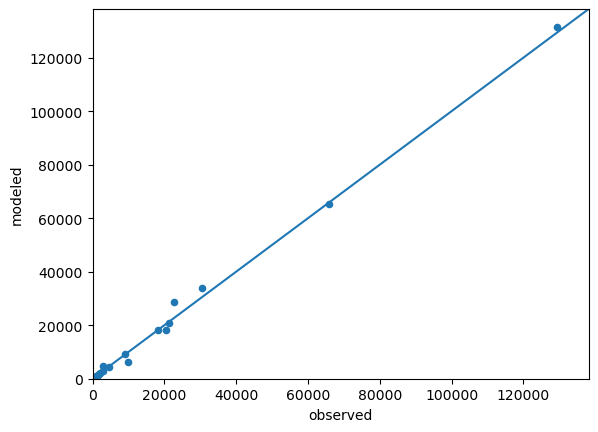

In [35]:
df = df.head(-1)
ax = df.plot(kind='scatter', x='observed', y='modeled')
lim = df[['observed','modeled']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['observed'],df['modeled'])
print('r^2 : ' + str(r_value))

In [36]:
## External trips/VMT
df_23 = h5py.File(r'..\..\..\..\inputs\model\daysim\roster\7to8.h5')
df_23_skims_sov = df_23['Skims']['sov_inc2d'][:]/100
df_23_skims_hov2 = df_23['Skims']['hov2_inc2d'][:]/100
df_23_skims_hov3 = df_23['Skims']['hov3_inc2d'][:]/100

df_results_new = pd.DataFrame()

tod_list = ['5to6', '6to7', '7to8', '8to9', '9to10', '10to14', '14to15', '15to16', '16to17', '17to18', '18to20', '20to5']
for tod in tod_list:
#     print(tod)
    df_temp = pd.DataFrame()
    for mode in ['sov','hov2','hov3']:
#         print(mode)
        od_new = h5py.File(r'..\..\..\..\outputs\supplemental\external_work_'+tod+'.h5', 'r')[mode][:]
        df_temp.loc[tod,mode+'_vmt'] = (df_23_skims_sov*od_new).sum()
        df_temp.loc[tod,mode+'_trips'] = od_new.sum()
        df_temp.loc[tod,mode+'_avg_dist'] = df_temp.loc[tod,mode+'_vmt']/df_temp.loc[tod,mode+'_trips']
    df_results_new = pd.concat([df_results_new, df_temp ])

In [37]:
df_vmt = pd.DataFrame(df_results_new[['sov_vmt','hov2_vmt','hov3_vmt']].sum(),
            columns=['VMT'])
df_vmt.index = [i.split('_')[0].upper() for i in df_vmt.index]

df_trips = pd.DataFrame(df_results_new[['sov_trips','hov2_trips','hov3_trips']].sum(),
            columns=['Trips'])
df_trips.index = [i.split('_')[0].upper() for i in df_trips.index]

df = df_vmt.merge(df_trips, left_index=True, right_index=True)

df.loc['Total',:] = df.sum(axis=0)
df['Avg Distance'] = df['VMT']/df['Trips']
df

,VMT,Trips,Avg Distance
SOV,"7,550,874","237,921",32
HOV2,"573,711","18,448",31
HOV3,"211,470","6,432",33
Total,"8,336,055","262,801",32


# Trucks

In [38]:
daily_counts = pd.read_sql("SELECT * FROM daily_counts WHERE year="+str(input_config['base_year']), con=conn)

daily_counts['htrk_vehicles'] = daily_counts['htrk_vehicles'].astype('float').fillna(-1)

facility_type_lookup = {
    1: "Freeway",  # Interstate
    2: "Freeway",  # Ohter Freeway
    3: "Freeway",  # Expressway
    4: "Ramp",
    5: "Arterial",  # Principal arterial
    6: "Arterial",  # Minor Arterial
    7: "Collector",  # Major Collector
    8: "Collector",  # Minor Collector
    9: "Collector",  # Local
    10: "Busway",
    11: "Non-Motor",
    12: "Light Rail",
    13: "Commuter Rail",
    15: "Ferry",
    16: "Passenger Only Ferry",
    17: "Connector",  # centroid connector
    18: "Connector",  # facility connector
    19: "HOV",  # HOV Only Freeway
    20: "HOV",  # HOV Flag
}

In [39]:
# FIXME: move to validation.py
df_network = pd.read_csv(r"..\..\..\..\outputs\network\network_results.csv")
model_vol_df = df_network.copy()
model_vol_df["@facilitytype"] = model_vol_df["@facilitytype"].map(
    facility_type_lookup
)

# Get daily and model volumes
df_daily = (
    model_vol_df.groupby(["@countid"])
    .agg({"@tveh": "sum", "@facilitytype": "first", '@mveh': 'sum', '@hveh': 'sum'})
    .reset_index()
)

# Merge observed with model
df_daily = df_daily.merge(daily_counts, left_on="@countid", right_on="flag")

In [40]:
county_lookup = {
    33: 'King',
    35: 'Kitsap',
    53: 'Pierce',
    61: 'Snohomish'
}

df_daily['County'] = df_daily['countyid'].map(county_lookup)

In [41]:
df_daily_med = df_daily.copy()
df_daily_med.rename(columns={'@mveh': 'Model', 'mtrk_vehicles': 'Observed'}, inplace=True)
df_daily_med = df_daily_med[~df_daily_med['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_med[col] = df_daily_med[col].astype('int')
df_daily_med = df_daily_med[df_daily_med['Observed'] > 0]

df_daily_heavy = df_daily.copy()
df_daily_heavy.rename(columns={'@hveh': 'Model', 'htrk_vehicles': 'Observed'}, inplace=True)
df_daily_heavy = df_daily_heavy[~df_daily_heavy['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_heavy[col] = df_daily_heavy[col].astype('int')
df_daily_heavy = df_daily_heavy[df_daily_heavy['Observed'] > 0]

In [42]:
def create_truck_chart(df_daily, truck_type, county=None):

    if county:
        df_daily = df_daily[df_daily['County'] == county]
        title = truck_type + ' Trucks: '+county
    else:
        title = truck_type + ' Trucks: Region'

    slope, intercept, r_value, p_value, std_err = stats.linregress(df_daily['Observed'], df_daily['Model'])

    fig = px.scatter(df_daily, y='Model', x='Observed', title=title, hover_data=['location','County'])
    fig.update_layout(height=600, width=800, margin=dict(l=100, r=100, t=100, b=100))

    # Get max value, either observed or modeled
    max_val = df_daily[['Observed','Model']].max().max()

    # Add 45-degree line
    fig.add_shape(
        type="line",
        x0=0, y0=0,
        x1=max_val, y1=max_val,
        line=dict(color="Red", width=2, dash="dash")
    )

    # Add best fit line
    x_fit = np.linspace(0, max(df_daily['Observed']), 100)
    y_fit = slope * x_fit + intercept
    fig.add_trace(px.line(x=x_fit, y=y_fit, labels={'x':'Observed', 'y':'Model'}).data[0])
    fig.update_traces(line=dict(color="Grey", width=2))

    # Add label for 45-degree line

    fig.add_annotation(
        x=max_val*1.05,
        y=max_val*1.05,
        text='y = x',
        showarrow=False,
        font=dict(size=12, color="pink"),
        align="right"
    )

    # Add R-squared value as annotation
    fig.add_annotation(
        x=max(x_fit)*1.05,
        y=max(y_fit)*1.05,
        text=f'r^2 = {r_value**2:.2f}',
        showarrow=False,
        font=dict(size=12, color="black"),
        align="right"
    )

    return fig


### Heavy Truck Counts

In [43]:
_df = df_daily_heavy.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"296,613","395,507","98,894",33.3%
Arterial,"83,966","53,263","-30,703",-36.6%
Collector,"2,372",723,"-1,649",-69.5%
Ramp,"1,865","3,476","1,611",86.4%
Total,"384,816","452,969","68,153",17.7%


In [44]:
fig = create_truck_chart(df_daily_heavy, 'Heavy')
fig.show()

In [45]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'King')
fig.show()

In [46]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Kitsap')
fig.show()

In [47]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Pierce')
fig.show()

In [48]:
fig = create_truck_chart(df_daily_heavy, 'Heavy', 'Snohomish')
fig.show()

### Medium Truck Counts

In [49]:
_df = df_daily_med.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])

,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"263,313","327,108","63,795",24.2%
Arterial,"209,328","164,557","-44,771",-21.4%
Collector,"19,046","4,050","-14,996",-78.7%
Ramp,"4,927","5,977","1,050",21.3%
Total,"496,614","501,692","5,078",1.0%


In [50]:
fig = create_truck_chart(df_daily_med, 'Medium')
fig.show()

In [51]:
fig = create_truck_chart(df_daily_med, 'Medium', 'King')
fig.show()

In [52]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Kitsap')
fig.show()

In [53]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Pierce')
fig.show()

In [54]:
fig = create_truck_chart(df_daily_med, 'Medium', 'Snohomish')
fig.show()

### Total Truck Counts

In [55]:
df_daily_total = df_daily.copy()
df_daily_total['Model'] = df_daily_total['@mveh'] + df_daily_total['@hveh']
df_daily_total['Observed'] = df_daily_total['mtrk_vehicles'] + df_daily_total['htrk_vehicles']
df_daily_total = df_daily_total[~df_daily_total['Observed'].isnull()]
for col in ['Model','Observed']:
    df_daily_total[col] = df_daily_total[col].astype('int')
df_daily_total = df_daily_total[df_daily_total['Observed'] > 0]
_df = df_daily_total.groupby('@facilitytype').sum()[['Observed','Model']].rename(columns={'Model':'modeled','Observed':'observed'})
_df.loc['Total',:] = _df.sum().values
_df['diff'] = _df['modeled']-_df['observed']
_df['percent_diff'] = _df['diff']/_df['observed']
_df['percent_diff'] = _df['percent_diff'].apply(format_percent)
_df.reindex(['Freeway', 'Arterial', 'Collector', 'Ramp', 'Total'])


,observed,modeled,diff,percent_diff
@facilitytype,,,,
Freeway,"559,927","722,680","162,753",29.1%
Arterial,"293,347","217,935","-75,412",-25.7%
Collector,"21,444","4,798","-16,646",-77.6%
Ramp,"6,792","9,454","2,662",39.2%
Total,"881,510","954,867","73,357",8.3%


r^2: 0.8229698940170285


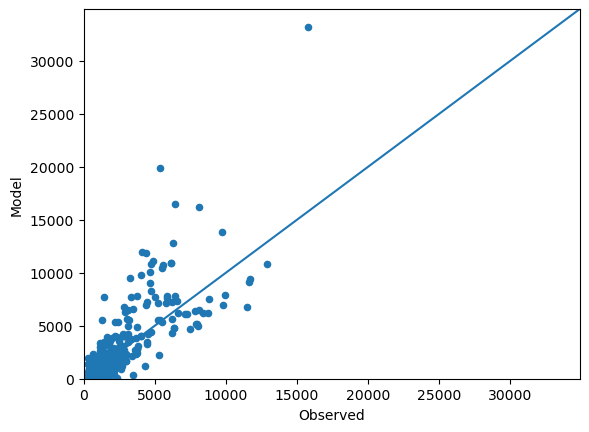

In [56]:
ax = df_daily_total.plot(kind='scatter', x='Observed', y='Model')
lim = df_daily_total[['Observed','Model']].max().max()*1.05
ax.set_ylim(0,lim)
ax.set_xlim(0,lim)
x = np.linspace(*ax.get_xlim())
ax.plot(x, x)
slope, intercept, r_value, p_value, std_err = stats.linregress(df_daily_total['Observed'],df_daily_total['Model'])
print('r^2: ' + str(r_value))